# Gemeinsamer Klassifikator: ResNet-18 (XRay)

Trainiert den **einen** Klassifikator, den alle Methoden im Vergleich erklären
(Mirror-CFE, Wachter, CFProto, FCVE): torchvision-ResNet-18, 224×224,
Normierung mean/std = 0.5, Adam 2e-4 — Daten, Klassenregeln und Split identisch
zu allen Methoden-Notebooks.

Export nach `trained_classifiers/resnet18_xray_224.pth`
(reiner torchvision-`state_dict` + Metadaten). Diese Datei neben die
Methoden-Notebooks legen (bzw. auf Kaggle als Input hochladen).

## 1. Setup & Konfiguration

Hyperparameter wie im Paper (Adam $2\cdot10^{-4}$, $\alpha=0.2$, gleiche Verlustgewichte).

**Ausführung auf einem Cluster:**
- Benötigte Pakete: `torch`, `torchvision`, `matplotlib`, `pillow`, `pandas`, `scikit-learn`, `scipy` (FID), `kagglehub` (Datensatz-Download); optional `lpips` für die LPIPS-Metrik.
- Der Datenpfad wird automatisch erkannt (`/kaggle/input/...` oder kagglehub-Cache); sonst wird der Datensatz einmalig per `kagglehub` heruntergeladen — **Achtung: die vollen NIH Chest X-rays sind ~42 GB.** Liegt der Datensatz bereits auf dem Cluster, den Pfad (Ordner mit `Data_Entry_2017.csv` und `images_*/images/`) in der Umgebungsvariable `MIRROR_XRAY_DATA` setzen.
- Checkpoints landen in `mirror_cfe_checkpoints/`; beim erneuten Ausführen werden sie geladen statt neu trainiert (`RETRAIN_* = True` zum Überschreiben).

**Bildgröße:** Standardmäßig 224×224 — wie in der bestehenden Kaggle-Pipeline; die letzte Feature-Map ist dann 512×7×7. Der Code ist größenunabhängig: Auf schwacher Hardware kann `img_size = 128` gesetzt werden (Paper nutzt 128 für B-MNIST; Feature-Map dann 512×4×4).

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F          # Achtung: der Encoder des Papers heißt ebenfalls F,
import torchvision                        # hier heißt der Klassifikator deshalb `clf`
import torchvision.transforms.functional as TF
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset, random_split, WeightedRandomSampler
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

QUICK_TEST = os.environ.get('MIRROR_QUICK', '0') == '1'

# Kaggle-Datenpfad: fester Organizations-Pfad wie in den anderen Notebooks
DATA_DIR = '/kaggle/input/datasets/organizations/nih-chest-xrays/data'
assert os.path.exists(os.path.join(DATA_DIR, 'Data_Entry_2017.csv')), \
    f'Data_Entry_2017.csv nicht gefunden unter {DATA_DIR} - Datensatz als Kaggle-Input hinzufügen.'
print('Datensatz:', DATA_DIR)

NUM_WORKERS = 4 if device.type == 'cuda' else 0   # auf dem Cluster parallel laden

CFG = dict(
    img_size    = 224,                     # wie die bestehende Kaggle-Pipeline (128 als speichersparende Option)
    num_classes = 2,
    class_names = {0: 'No Finding', 1: 'Infiltration'},   # wie in der Vorlage
    batch_size  = 32,
    lr          = 2e-4,                    # Adam (Paper)
    epochs_classifier = 1 if QUICK_TEST else 10,
    ckpt_dir    = 'mirror_cfe_checkpoints',
)
os.makedirs(CFG['ckpt_dir'], exist_ok=True)

RETRAIN_CLASSIFIER = False

suffix    = '_quick' if QUICK_TEST else ''
CLF_CKPT  = os.path.join(CFG['ckpt_dir'], f'resnet18_xray{suffix}.pt')
if QUICK_TEST:
    print('QUICK_TEST aktiv: reduzierte Daten/Epochen (nur Funktionstest!)')

Device: cuda
Datensatz: /kaggle/input/datasets/organizations/nih-chest-xrays/data


## 2. Daten: NIH Chest X-rays & Klassenpaar

Aufbereitung **identisch zur bestehenden Pipeline** (`mirrorcfe-xray.ipynb`): Aus `Data_Entry_2017.csv` werden nur Bilder mit `No Finding` (Klasse 0) oder einem Befund, der `Infiltration` enthält (Klasse 1), behalten. Der Split ist patientenbasiert (`GroupShuffleSplit`, 70/15/15, `random_state=42`), damit kein Patient gleichzeitig in Training und Test vorkommt. Trainiert wird auf dem Train-Split, evaluiert auf dem Test-Split.

Die Bilder werden auf `IMG_SIZE`² skaliert und auf $[-1,1]$ normiert.

In [2]:
import pandas as pd
from glob import glob
from sklearn.model_selection import GroupShuffleSplit

IMG = CFG['img_size']
tfm = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),   # -> [-1, 1]
])

# CSV laden und Binaerlabel zuweisen - identisch zur Vorlage
all_xray_df = pd.read_csv(os.path.join(DATA_DIR, 'Data_Entry_2017.csv'))
all_image_paths = {os.path.basename(x): x
                   for x in glob(os.path.join(DATA_DIR, 'images_*', 'images', '*.png'))}
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)

def assign_binary_label(finding):
    if finding == 'No Finding':
        return 0
    elif 'Infiltration' in finding:
        return 1
    return None

all_xray_df['binary_label'] = all_xray_df['Finding Labels'].map(assign_binary_label)
all_xray_df = all_xray_df.dropna(subset=['binary_label', 'path']).copy()
all_xray_df['binary_label'] = all_xray_df['binary_label'].astype(int)
print('Klassenverteilung:')
print(all_xray_df['binary_label'].value_counts()
      .rename(CFG['class_names']).to_string())

# Patientenbasierter Split 70/15/15, random_state 42 - identisch zur Vorlage
splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_i, temp_i = next(splitter.split(all_xray_df, groups=all_xray_df['Patient ID']))
train_df = all_xray_df.iloc[train_i].reset_index(drop=True)
temp_df  = all_xray_df.iloc[temp_i].reset_index(drop=True)
splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_i, test_i = next(splitter2.split(temp_df, groups=temp_df['Patient ID']))
test_df = temp_df.iloc[test_i].reset_index(drop=True)
assert len(set(train_df['Patient ID']) & set(test_df['Patient ID'])) == 0

if QUICK_TEST:
    train_df = train_df.iloc[:256].reset_index(drop=True)
    test_df  = test_df.iloc[:128].reset_index(drop=True)

class XRayDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.targets = self.df['binary_label'].tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row['path']).convert('RGB')
        return self.transform(img), int(row['binary_label'])

train_ds = XRayDataset(train_df, tfm)
test_ds  = XRayDataset(test_df, tfm)

# WeightedRandomSampler: gleicht die 75/25-Imbalance im Training aus, ohne
# No-Finding-Bilder wegzuwerfen (Infiltration wird pro Batch effektiv ~50/50
# so oft gezogen wie No Finding). Test-Loader bleibt unveraendert/ungewichtet,
# damit die Test-Genauigkeit weiterhin die echte Verteilung widerspiegelt.
class_counts    = np.bincount(train_ds.targets)                      # [n_no_finding, n_infiltration]
class_weights   = 1.0 / class_counts
sample_weights  = [class_weights[y] for y in train_ds.targets]
train_sampler   = WeightedRandomSampler(sample_weights, num_samples=len(train_ds), replacement=True)
print(f'Klassengewichte (Sampler): No Finding={class_weights[0]:.6f} | '
      f'Infiltration={class_weights[1]:.6f}')

pair_train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                               sampler=train_sampler, drop_last=True, num_workers=NUM_WORKERS)
pair_test_loader  = DataLoader(test_ds, batch_size=64,
                               shuffle=False, num_workers=NUM_WORKERS)

# binaeres Klassenpaar: No Finding <-> Infiltration
pair_of = {0: 1, 1: 0}

# Index-Pools je Klasse (Trainingssplit) fuer x_t / x_ss im Triangulationsverlust
class_pool = {c: [i for i, y in enumerate(train_ds.targets) if y == c] for c in (0, 1)}

def sample_class_images(labels):
    """Zieht zu jedem Label ein zufaelliges echtes Trainingsbild dieser Klasse."""
    idx = [random.choice(class_pool[int(c)]) for c in labels]
    return torch.stack([train_ds[i][0] for i in idx])

print(f'Train: {len(train_ds)} | Test: {len(test_ds)}')

Klassenverteilung:
binary_label
No Finding      60361
Infiltration    19894
Klassengewichte (Sampler): No Finding=0.000023 | Infiltration=0.000071
Train: 56768 | Test: 11561


## 3. Klassifikator $F$: ResNet-18

Torchvision-ResNet-18 mit Standard-Stem (7×7-Faltung + MaxPool) für RGB-Bilder. Bei 224×224-Eingaben ist die letzte Feature-Map $\mathbf{f}^l$ **512×7×7**; alle Methoden-Bausteine sind größenunabhängig. Skip-Features: $\mathbf{f}^1$ (64×56×56), $\mathbf{f}^2$ (128×28×28), $\mathbf{f}^3$ (256×14×14).

In [3]:
class ResNet18XRay(nn.Module):
    """Torchvision-ResNet-18 (Standard-Stem) mit Feature-Zugriff wie in der MNIST-Version."""

    def __init__(self, num_classes=2):
        super().__init__()
        self.base = torchvision.models.resnet18(weights=None, num_classes=num_classes)

    def features(self, x):
        """[f1, f2, f3, f4]: (64,56,56), (128,28,28), (256,14,14), (512,7,7) bei 224er-Eingabe."""
        b = self.base
        x = b.maxpool(b.relu(b.bn1(b.conv1(x))))
        f1 = b.layer1(x)
        f2 = b.layer2(f1)
        f3 = b.layer3(f2)
        f4 = b.layer4(f3)
        return [f1, f2, f3, f4]

    def encode(self, x):
        """z = GAP(f^l)"""
        return self.features(x)[-1].mean(dim=(2, 3))

    def forward(self, x):
        return self.base.fc(self.encode(x))

clf = ResNet18XRay(CFG['num_classes']).to(device)
print(sum(p.numel() for p in clf.parameters()) / 1e6, 'Mio. Parameter')

11.177538 Mio. Parameter


In [4]:
def test_accuracy(model, loader):
    model.eval()
    correct = total = 0
    per_class = {0: [0, 0], 1: [0, 0]}
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item(); total += len(y)
            for c in (0, 1):
                m = y == c
                per_class[c][0] += (pred[m] == c).sum().item()
                per_class[c][1] += int(m.sum())
    return correct / total, {c: v[0] / max(v[1], 1) for c, v in per_class.items()}

history = {'train_loss': [], 'test_acc': [], 'balanced_acc': []}
best_bacc = -1.0

if os.path.exists(CLF_CKPT) and not RETRAIN_CLASSIFIER:
    clf.load_state_dict(torch.load(CLF_CKPT, map_location=device))
    print('Klassifikator aus Checkpoint geladen (keine Trainingshistorie verfügbar).')
else:
    opt = torch.optim.Adam(clf.parameters(), lr=CFG['lr'])   # Adam 2e-4 (Paper)
    for epoch in range(CFG['epochs_classifier']):
        clf.train()
        running_loss, n_batches = 0.0, 0
        for x, y in pair_train_loader:
            x, y = x.to(device), y.to(device)
            loss = F.cross_entropy(clf(x), y)
            opt.zero_grad(); loss.backward(); opt.step()
            running_loss += loss.item(); n_batches += 1
        epoch_loss = running_loss / n_batches
        epoch_acc, epoch_per_class = test_accuracy(clf, pair_test_loader)
        # Balanced statt roher Accuracy, sonst waere "bestes" Modell bei 3:1-Imbalance
        # einfach das mehrheitslastigste (siehe No-Finding/Infiltration-Luecke).
        epoch_bacc = sum(epoch_per_class.values()) / len(epoch_per_class)
        history['train_loss'].append(epoch_loss)
        history['test_acc'].append(epoch_acc)
        history['balanced_acc'].append(epoch_bacc)

        improved = epoch_bacc > best_bacc
        if improved:
            best_bacc = epoch_bacc
            torch.save(clf.state_dict(), CLF_CKPT)   # bestes Modell (nach Balanced-Acc) sichern

        print(f'Epoche {epoch + 1}/{CFG["epochs_classifier"]} '
              f'- Train-Loss: {epoch_loss:.4f} - Test-Acc: {epoch_acc:.4f} '
              f'- Balanced-Acc: {epoch_bacc:.4f}' + (' *' if improved else ''))
    clf.load_state_dict(torch.load(CLF_CKPT, map_location=device))   # bestes Modell zurueckladen
    print(f'Bestes Modell zurueckgeladen (Balanced-Acc: {best_bacc:.4f})')

acc, per_class = test_accuracy(clf, pair_test_loader)
print(f'Test-Genauigkeit: {acc:.4f} | No Finding: {per_class[0]:.4f} | Infiltration: {per_class[1]:.4f}')

# Klassifikator einfrieren: F ist reiner Encoder/Entscheider und wird NIE feinjustiert (Faithfulness).
for p in clf.parameters():
    p.requires_grad_(False)
clf.eval()

W_fc = clf.base.fc.weight.detach()   # W  (2 x 512)
b_fc = clf.base.fc.bias.detach()     # b  (2)

Epoche 1/10 - Train-Loss: 0.6274 - Test-Acc: 0.7079 - Balanced-Acc: 0.6411 *
Epoche 2/10 - Train-Loss: 0.6019 - Test-Acc: 0.7211 - Balanced-Acc: 0.6443 *
Epoche 3/10 - Train-Loss: 0.5840 - Test-Acc: 0.7233 - Balanced-Acc: 0.6510 *
Epoche 4/10 - Train-Loss: 0.5555 - Test-Acc: 0.6707 - Balanced-Acc: 0.6555 *
Epoche 5/10 - Train-Loss: 0.4968 - Test-Acc: 0.6552 - Balanced-Acc: 0.6260
Epoche 6/10 - Train-Loss: 0.3965 - Test-Acc: 0.6807 - Balanced-Acc: 0.6241
Epoche 7/10 - Train-Loss: 0.2865 - Test-Acc: 0.6973 - Balanced-Acc: 0.6143
Epoche 8/10 - Train-Loss: 0.2062 - Test-Acc: 0.6797 - Balanced-Acc: 0.6091
Epoche 9/10 - Train-Loss: 0.1572 - Test-Acc: 0.6837 - Balanced-Acc: 0.6135
Epoche 10/10 - Train-Loss: 0.1265 - Test-Acc: 0.7179 - Balanced-Acc: 0.5984
Bestes Modell zurueckgeladen (Balanced-Acc: 0.6555)
Test-Genauigkeit: 0.6707 | No Finding: 0.6848 | Infiltration: 0.6261


### Klassifikator-Export für andere Methoden

Der trainierte ResNet-18 wird zusätzlich als **portabler Checkpoint** unter `trained_classifiers/` gespeichert: ein reiner torchvision-`state_dict` (ohne Wrapper-Präfix) plus Metadaten (Bildgröße, Normierung, Klassennamen, Split, Genauigkeit). Andere Methoden (z. B. Wachter, CFProto, FCVE) können ihn so laden:

```python
import torch, torchvision
ckpt  = torch.load('trained_classifiers/resnet18_xray_224.pth', map_location='cpu')
model = torchvision.models.resnet18(num_classes=len(ckpt['class_names']))
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
# Eingaben: RGB, ckpt['img_size']², normiert mit ckpt['normalization_mean']/_std (also [-1,1])
```

In [5]:
# Portabler Export: reiner torchvision-state_dict + Metadaten, damit derselbe
# Klassifikator auch von anderen (CFE-)Methoden wiederverwendet werden kann.
os.makedirs('trained_classifiers', exist_ok=True)
EXPORT_PATH = os.path.join('trained_classifiers', f'resnet18_xray_{IMG}{suffix}.pth')
torch.save({
    'model_state_dict': {k.replace('base.', '', 1): v.cpu()
                          for k, v in clf.state_dict().items()},
    'arch': 'torchvision resnet18(num_classes=2)',
    'dataset': 'NIH Chest X-rays (No Finding=0 / Infiltration=1, wie mirrorcfe-xray.ipynb)',
    'img_size': IMG,
    'normalization_mean': [0.5, 0.5, 0.5],
    'normalization_std':  [0.5, 0.5, 0.5],
    'class_names': CFG['class_names'],
    'split': 'patientenbasiert 70/15/15, GroupShuffleSplit(random_state=42)',
    'test_accuracy': acc,
    'per_class_accuracy': per_class,
}, EXPORT_PATH)
print('Klassifikator exportiert:', EXPORT_PATH)

Klassifikator exportiert: trained_classifiers/resnet18_xray_224.pth


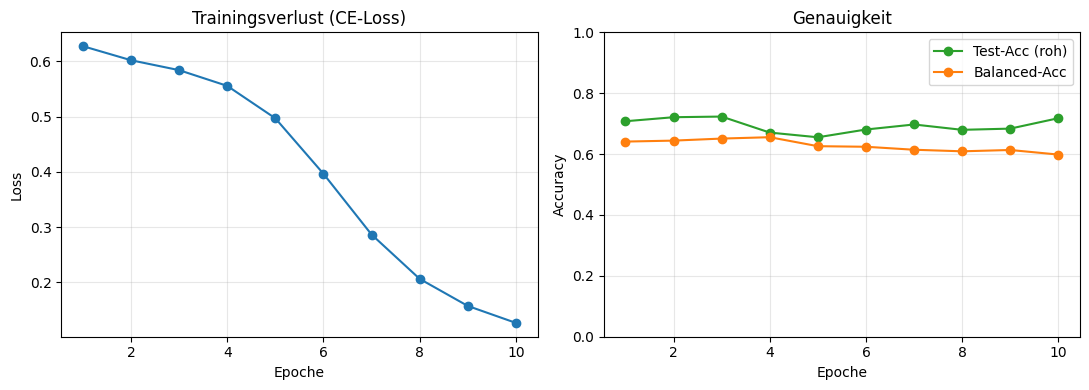

In [6]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs_range, history['train_loss'], marker='o', color='tab:blue')
axes[0].set_title('Trainingsverlust (CE-Loss)')
axes[0].set_xlabel('Epoche'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['test_acc'], marker='o', color='tab:green', label='Test-Acc (roh)')
axes[1].plot(epochs_range, history['balanced_acc'], marker='o', color='tab:orange', label='Balanced-Acc')
axes[1].set_title('Genauigkeit')
axes[1].set_xlabel('Epoche'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1); axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves_xray.png', dpi=150, bbox_inches='tight')
plt.show()

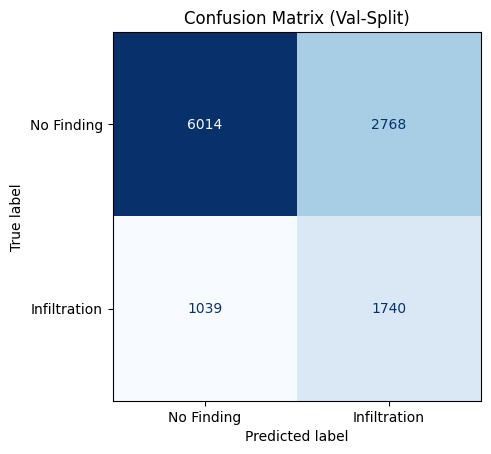

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

clf.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in pair_test_loader:
        x = x.to(device)
        preds = clf(x).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(y)
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=[CFG['class_names'][0], CFG['class_names'][1]])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title('Confusion Matrix (Val-Split)')
plt.tight_layout()
plt.savefig('confusion_matrix_fire.png', dpi=150, bbox_inches='tight')
plt.show()